# Factorización Probabilística de Matrices (PMF)

---

## Indice

```
1. Motivación: el problema de la recomendación de contenido
2. El modelo PMF: derivación matemática
   2.1 Modelo lineal-gaussiano
   2.2 Priors gaussianos
   2.3 Log-posterior y función objetivo
   2.4 Extensión logística
3. Gradiente descendente: derivación de las actualizaciones
4. Implementación en NumPy
5. Experimento con MovieLens-100K
6. Ejemplo de uso
```

**Bibliografía usada para este cuaderno:**
- Ruslan Salakhutdinov and Andriy Mnih. 2007. Probabilistic Matrix Factorization. In Proceedings of the 21st International Conference on Neural Information Processing Systems (NIPS'07). Curran Associates Inc., Red Hook, NY, USA, 1257–1264.
- Delbert Dueck and Brendan Frey. 2004. Probabilistic sparse matrix factorization. Technical Report PSI, Dept. of Computer Science, University of Toronto, 2004.

---
## 1. Motivación: el problema de la recomendación de contenido

Imaginemos que tenemos $N$ usuarios y $M$ películas. Cada usuario calificó *algunas* películas con un puntaje del 1 al 5. El objetivo es **predecir las calificaciones faltantes** para recomendar nuevas películas.

### La matriz de calificaciones $R$

$$R \in \mathbb{R}^{N \times M}, \quad R_{ij} \in \{1, 2, 3, 4, 5\} \text{ si el usuario } i \text{ calificó la película } j$$

El problema con este tipo de matrices es que por lo general son matrices incompletas (*sparsity*). En las bases de datos reales, menos del 10% de las entradas están completas. Plataformas como Netflix o Amazon Prime poseen enormes cantidades de películas en sus repositorios. Pero los usuarios de estas plataformas no han proporcionado calificaciones para todas esas películas (la mayor parte, solo ha calificado unas pocas películas o ninguna) ¿cómo podemos recomendarle contenido a un usuario, si conocemos tan poco acerca de sus preferencias?

### La hipótesis central de PMF

> Cada usuario y cada película pueden ser descritos por un **vector de características latentes** de dimensión $D$. La calificación que un usuario le daría a una película es aproximadamente el **producto punto** de sus vectores latentes.

$$R_{ij} \approx U_i^T V_j$$

Donde:
- $U_i \in \mathbb{R}^D$: características latentes del usuario $i$
- $V_j \in \mathbb{R}^D$: características latentes de la película $j$

**Intuición**: si $D=2$, un usuario podría tener coordenadas `[le_gustan_dramas=0.9, le_gustan_comedias=0.2]`, y una película `[es_drama=0.8, es_comedia=0.1]`. Su producto daría una calificación alta.

La pregunta es: **¿cómo aprendemos $U$ y $V$ a partir de las calificaciones observadas, de forma robusta y probabilística?** Eso es exactamente lo que resuelve PMF.

---
## 2. El modelo PMF: derivación matemática

### 2.1 Modelo de observación: distribución condicional

El punto de partida de PMF es especificar un modelo generativo para los datos: una descripción probabilística del proceso mediante el cual se generan los ratings observados. Se asume que cada calificación $R_{ij}$ es una realización de una variable aleatoria gaussiana cuya media es el producto interno entre los vectores latentes $U$ y $V$. En términos formales:

$$p(R \mid U, V, \sigma^2) = \prod_{i=1}^{N} \prod_{j=1}^{M} \left[ \mathcal{N}(R_{ij} \mid U_i^T V_j,\sigma^2) \right]^{I_{ij}}$$

donde $I_{ij}$ es la **función indicadora** que vale 1 si el usuario $i$ calificó la película $j$, y 0 en caso contrario. El exponente $I_{ij}$ hace que solo contribuyan al producto los pares efectivamente observados.

Ahora bien, **¿por qué los autores optaron por la distribución normal?** La elección no es arbitraria. Puede justificarse desde dos ángulos complementarios. Por un lado, la gaussiana es la distribución de máxima entropía sujeta a una varianza fija: asume lo mínimo posible sobre la estructura del ruido. Por otro lado, tenemos la equivalencia con mínimos cuadrados. El logaritmo de una densidad gaussiana tiene la forma 
$$
p(R \mid \mu_{ij}, \sigma^2) = -\frac{1}{2}\log(2\pi\sigma^2)-\frac{(R_{ij}-\mu_{ij})^2}{2\sigma^2}
$$
donde $\mu_{ij}=U_i^T V_j$. El primer término es una constante que no depende de $U$ ni de $V$. Al sumar sobre todos los pares observados, el log-likelihood completo queda:
$$
\log p(R \mid U, V, \sigma^2) = \underbrace{-\frac{N_{obs}}{2}*\log(2\pi\sigma^2)}_{constante}-\frac{1}{2\sigma^2}\sum_{i,j}I_{i,j}(R_{ij}-U_i^T V_j)^2
$$
Maximizar esto respecto a $U$ y $V$ equivale a maximizar solo el segundo término. Como el prefactor $-\frac{1}{2\sigma^2}$ es negativo,
maximizar el log-likelihood es algebraicamente idéntico a minimizar la suma de errores al cuadrado:
$$
\log p(R \mid U, V, \sigma^2) \propto -\frac{1}{2\sigma^2} \sum_{i,j} I_{ij} \left(R_{ij} - U_i^T V_j\right)^2
$$

---

### 2.2 Priors sobre los factores latentes

Con la verosimilitud definida, el segundo componente del modelo son las **distribuciones a priori** (*priors*) sobre los parámetros desconocidos $U$ y $V$. Los priors representan conocimiento o las creencias que se tienen sobre los parámetros *antes* de observar los datos. PMF adopta priors gaussianos de media cero e isótropos sobre cada vector latente:

$$p(U \mid \sigma_U^2) = \prod_{i=1}^{N} \mathcal{N}(U_i \mid 0,\ \sigma_U^2 I)$$

$$p(V \mid \sigma_V^2) = \prod_{j=1}^{M} \mathcal{N}(V_j \mid 0,\ \sigma_V^2 I)$$

El adjetivo **esférico** (o isótropo) se refiere a que la matriz de covarianza es $\sigma_U^2 I$. Esto implica que la varianza es idéntica en cada una de las $D$ dimensiones y que no existe correlación entre ellas. La elección de priors isótropos por parte de los autores expresa la creencia de que, *a priori*, ninguna dimensión latente es más informativa que otra.

Pero... ¿por qué media cero? Aquí aparecen varios elementos que están conectados entre sí.

**1) El problema de optimización está subdeterminado.** Para la PMF, los vectores latentes no tienen una escala o signo canónico. La factorización matricial tiene una simetría fundamental: reescalar $U_i \to c\,U_i$ y $V_j \to \frac{1}{c}V_j$ deja el producto $U_i^T V_j$ exactamente invariante para cualquier $c \neq 0$. Hay infinitas parametrizaciones con el mismo valor de verosimilitud y el modelo no puede distinguir entre ellas usando solamente los datos de la matriz.

**2) Un prior centrado en el origen es la elección neutral.** No favorece ningún escalado en particular ni ningún signo canónico, evitando introducir un sesgo arbitrario en el resultado del optimizador.

**3) Sin regularización, los vectores crecen sin límite.** Cuando los datos son escasos, el gradiente siempre puede aumentar la norma de los vectores para ajustarse mejor al ruido. El prior gaussiano actúa como una fuerza restauradora que mantiene las normas bajo control.


---

**Conexión con regularización L2**

Al comienzo de su artículo, los autores mencionan que existe una conexión entre el prior gaussiano y la regularización L2. Para verla, hay que incorporar el prior al log-posterior y desarrollar los pasos explícitamente.

El punto de partida es la forma general de la densidad gaussiana multivariada para un vector $U_i \in \mathbb{R}^D$ con media $\mu$ y matriz de covarianza $\Sigma$:

$$p(U_i \mid \mu, \Sigma) = \frac{1}{(2\pi)^{D/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(U_i - \mu)^T \Sigma^{-1} (U_i - \mu)\right)$$

En nuestro caso, $\mu = 0$ y $\Sigma = \sigma_U^2 I$. Hay que simplificar dos piezas:

**El determinante.** La matriz $\sigma_U^2 I$ es diagonal con $\sigma_U^2$ en cada una de las $D$ entradas. El determinante de una matriz diagonal es el producto de sus entradas:

$$|\sigma_U^2 I| = \underbrace{\sigma_U^2 \cdot \sigma_U^2 \cdots \sigma_U^2}_{D \text{ veces}} = (\sigma_U^2)^D$$

Por lo tanto $|\Sigma|^{1/2} = (\sigma_U^2)^{D/2}$, que es lo que aparece en el denominador.

**El exponente.** La inversa de $\sigma_U^2 I$ es $\frac{1}{\sigma_U^2} I$, porque:

$$\sigma_U^2 I \cdot \frac{1}{\sigma_U^2} I = I$$

Sustituyendo $\mu = 0$ y $\Sigma^{-1} = \frac{1}{\sigma_U^2} I$ en el exponente:

$$(U_i - 0)^T \left(\frac{1}{\sigma_U^2} I\right) (U_i - 0) = \frac{1}{\sigma_U^2} U_i^T U_i = \frac{\|U_i\|^2}{\sigma_U^2}$$

donde en el último paso se usó que $U_i^T U_i = \sum_{d=1}^D U_{id}^2 = \|U_i\|^2$ por definición de norma euclidiana.

Juntando ambas simplificaciones, la densidad queda:

$$p(U_i \mid \sigma_U^2) = \frac{1}{(2\pi\sigma_U^2)^{D/2}} \exp\left(-\frac{\|U_i\|^2}{2\sigma_U^2}\right)$$

Tomando logaritmo:

$$\log p(U_i \mid \sigma_U^2) = -\frac{D}{2}\log(2\pi\sigma_U^2) - \frac{\|U_i\|^2}{2\sigma_U^2}$$

El primer término es una constante que no depende del valor de los vectores — solo de la dimensión $D$ y del hiperparámetro $\sigma_U^2$. El segundo término es el único relevante para la optimización. Sumando sobre todos los usuarios (el producto $\prod_{i=1}^N$ se convierte en suma al tomar logaritmo):

$$\log p(U \mid \sigma_U^2) = \sum_{i=1}^{N} \log p(U_i \mid \sigma_U^2) = \underbrace{-\frac{ND}{2}\log(2\pi\sigma_U^2)}_{\text{constante}} - \frac{1}{2\sigma_U^2}\sum_{i=1}^{N}\|U_i\|^2$$

Cambiando de signo para obtener una penalización a minimizar y descartando la constante:

$$-\log p(U \mid \sigma_U^2) \propto \frac{1}{2\sigma_U^2}\sum_{i=1}^{N}\|U_i\|^2 = \frac{\lambda_U}{2}\sum_{i=1}^{N}\|U_i\|^2$$

Este es exactamente el término de regularización L2. Pero ¿por qué $\lambda_U = \sigma^2/\sigma_U^2$ y no simplemente $1/\sigma_U^2$? El $\sigma^2$ del numerador no viene del prior — viene de la verosimilitud. Cuando se escribe el log-posterior completo, todos los términos quedan en las mismas unidades:

$$-\log p(U, V \mid R) \propto \underbrace{\sum_{i,j} I_{ij}(R_{ij} - U_i^T V_j)^2}_{\text{error de reconstrucción}} + \underbrace{\frac{\sigma^2}{\sigma_U^2}\sum_{i=1}^{N} \|U_i\|^2}_{\lambda_U \cdot \text{penalización sobre } U} + \underbrace{\frac{\sigma^2}{\sigma_V^2}\sum_{j=1}^{M} \|V_j\|^2}_{\lambda_V \cdot \text{penalización sobre } V}$$

El cociente $\lambda_U = \sigma^2/\sigma_U^2$ es la relación entre cuánto ruido hay en las observaciones y cuánta libertad le damos a los vectores latentes. Lo que en optimización se llama **regularización L2** no es, desde esta perspectiva, un artificio computacional: es la expresión directa de un prior gaussiano. Y el hiperparámetro $\lambda_U$ no es un número elegido heurísticamente, sino el cociente entre dos varianzas con interpretación probabilística precisa:

- Si $\sigma_U^2$ es **grande** (prior difuso, poca convicción sobre el tamaño de los vectores) → $\lambda_U$ disminuye → regularización débil.
- Si $\sigma_U^2$ es **pequeño** (prior concentrado, esperamos vectores pequeños) → $\lambda_U$ crece → penalización fuerte.


#### Combinando verosimilitud y priors: la función objetivo

Por el teorema de Bayes, el posterior es proporcional al producto de la verosimilitud y los priors:

$$p(U, V \mid R) \propto p(R \mid U, V) \cdot p(U) \cdot p(V)$$

Conviene distinguir los tres términos, teniendo en cuenta lo dicho hasta el momento:

**Verosimilitud** $p(R \mid U, V)$ es la probabilidad de observar los ratings que tenemos *dado que los vectores latentes son $U$ y $V$

**Prior** $p(U) \cdot p(V)$ es la creencia sobre los vectores latentes *antes de ver ningún dato*. Las gaussianas esféricas dicen "espero que los vectores sean pequeños y centrados en el origen".

**Posterior** $p(U, V \mid R)$ es la creencia sobre los vectores latentes *después de haber observado los ratings*. Es lo que realmente queremos: ¿qué valores de $U$ y $V$ son más plausibles, en virtud de nuestras creencias previas y de lo que vimos en la matriz?


Tomando el logaritmo de la posterior, los productos que estaban en la parte derecha de la fórmula se convierten en sumas:

$$\log p(U, V \mid R,\, \sigma^2,\, \sigma_U^2,\, \sigma_V^2)
= -\frac{1}{2\sigma^2} \sum_{i,j} I_{ij}\left(R_{ij} - U_i^{\top} V_j\right)^2
-\frac{1}{2\sigma_U^2} \sum_{i=1}^{N} \|U_i\|^2
-\frac{1}{2\sigma_V^2} \sum_{j=1}^{M} \|V_j\|^2
+ C$$

donde $C$ agrupa todas las constantes independientes de $U$ y $V$.

**Maximizar** el log-posterior es equivalente a **minimizar** la función objetivo:

$$\boxed{E = \frac{1}{2}\sum_{i,j} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)^2
+ \frac{\lambda_U}{2}\sum_{i=1}^{N} \|U_i\|^2
+ \frac{\lambda_V}{2}\sum_{j=1}^{M} \|V_j\|^2}$$

con $\lambda_U = \sigma^2/\sigma_U^2$ y $\lambda_V = \sigma^2/\sigma_V^2$. Esta función objetivo es, como indican los propios autores, una implementación probabilística y regularizada de la *descomposición en valores singulares* (SVD) de la matriz de raitings. PMF le otorga una interpretación probabilística a una técnica conocida en el campo del algebra lineal, salvando los problemas que acarrea la incompletud de la matriz (*sparsity*).

---

### 2.3 Extensión logística

El modelo lineal tiene un defecto práctico: el producto $U_i^{\top}V_j$
es no acotado y puede predecir calificaciones fuera del rango $[1, 5]$.
Por ejemplo, si $U_1 = [3, 2]$ y $V_1 = [4, 3]$, el producto vale:

$$U_1^{\top}V_1 = 3 \cdot 4 + 2 \cdot 3 = 18$$

un valor que no tiene ningún significado como calificación. La solución
propuesta en el artículo tiene dos pasos.

**Paso 1: normalizar los ratings al intervalo $[0, 1]$.**
Se aplica la transformación:

$$t(x) = \frac{x - 1}{K - 1}, \qquad K = 5$$

Con esto, un rating de 1 se convierte en 0, un rating de 5 se convierte
en 1, y los valores intermedios quedan proporcionalmente distribuidos:

$$t(1) = 0, \quad t(2) = 0.25, \quad t(3) = 0.5, 
\quad t(4) = 0.75, \quad t(5) = 1$$

**Paso 2: acotar la predicción con la función logística.**
En lugar de usar el producto $U_i^{\top}V_j$ directamente como media,
se lo pasa por la función logística:

$$g(x) = \frac{1}{1 + e^{-x}} \in (0,\,1)$$

que comprime cualquier número real al intervalo abierto $(0, 1)$.
Siguiendo con el ejemplo anterior, donde $U_1^{\top}V_1 = 18$:

$$g(18) = \frac{1}{1 + e^{-18}} \approx 0.9999$$

Y si en cambio $U_1^{\top}V_1 = -5$:

$$g(-5) = \frac{1}{1 + e^{5}} \approx 0.0067$$

En ambos casos, la salida de $g$ pertenece a $(0, 1)$, independientemente
de cuán grande o pequeño sea el producto. La predicción desnormalizada
se recupera aplicando la transformación inversa $t^{-1}(\hat{y}) = 1 + \hat{y}\cdot(K-1)$:

$$t^{-1}(0.9999) \approx 4.99, \qquad t^{-1}(0.0067) \approx 1.03$$

Ambas predicciones caen dentro del rango válido $[1, 5]$.

El modelo de observación pasa a ser:

$$p(R \mid U, V, \sigma^2)
= \prod_{i=1}^{N}\prod_{j=1}^{M}
\left[\mathcal{N}\left(t(R_{ij}) \mid g(U_i^{\top}V_j),\;
\sigma^2\right)\right]^{I_{ij}}$$

La gaussiana ahora compara el rating observado normalizado $t(R_{ij})$
contra la media predicha $g(U_i^{\top}V_j)$, y ambas cantidades viven
en el mismo intervalo $(0, 1)$. La función $g$ garantiza que las
predicciones desnormalizadas $t^{-1}(\hat{R}_{ij})$ siempre caigan
dentro del rango válido $[1, 5]$.

## 3. Gradiente descendente: derivación de las actualizaciones

Con la función objetivo $E$ definida en el apartado anterior, el siguiente paso es especificar cómo optimizarla. PMF adopta el **gradiente descendente**: un algoritmo iterativo que actualiza los parámetros moviéndose, en cada paso, en la dirección opuesta al gradiente de $E$. La intuición geométrica es clara: el gradiente apunta en la dirección de máximo crecimiento local de la función, por lo que moverse en su opuesto garantiza, al menos localmente, reducir el error.

Esta sección deriva las expresiones del gradiente con respecto a cada vector latente, explica su interpretación, y formaliza la regla de actualización.

---

### 3.1 Gradiente respecto a $U_i$

Recordando la función objetivo:

$$
E = \underbrace{\frac{1}{2}\sum_{i,j} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)^2}_{\text{Error de reconstrucción}} + \underbrace{\frac{\lambda_U}{2}\sum_{i=1}^{N} \|U_i\|^2}_{\text{Reg. sobre } U} + \underbrace{\frac{\lambda_V}{2}\sum_{j=1}^{M} \|V_j\|^2}_{\text{Reg. sobre } V}
$$

Se busca $\frac{\partial E}{\partial U_i}$, el vector de derivadas parciales de $E$ respecto a cada componente de $U_i \in \mathbb{R}^D$. El tercer término no depende de $U_i$, por lo que su derivada es cero. Los otros dos se tratan por separado.

**Término de error de reconstrucción.** Fijado un usuario $i$, la contribución al error es:

$$E_{\text{rec},i} = \frac{1}{2}\sum_{j=1}^{M} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)^2$$

Sea $e_{ij} = R_{ij} - U_i^{\top}V_j$ el residuo para el par $(i,j)$. Aplicando la regla de la cadena:

$$\frac{\partial}{\partial U_i}\left[\frac{1}{2}e_{ij}^2\right] = e_{ij} \cdot \frac{\partial e_{ij}}{\partial U_i} = e_{ij} \cdot (-V_j) = -(R_{ij} - U_i^{\top}V_j)V_j$$

El signo negativo surge porque $e_{ij} = R_{ij} - U_i^{\top}V_j$ y la derivada de $-U_i^{\top}V_j$ respecto a $U_i$ es $-V_j$. Sumando sobre todas las películas observadas por el usuario $i$:

$$\frac{\partial E_{\text{rec},i}}{\partial U_i} = -\sum_{j=1}^{M} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)V_j$$

**Término de regularización.** La derivada de $\frac{\lambda_U}{2}\|U_i\|^2 = \frac{\lambda_U}{2} \sum_{d=1}^{D} U_{id}^2$ respecto al vector completo $U_i$ es:

$$\frac{\partial}{\partial U_i}\left[\frac{\lambda_U}{2}\|U_i\|^2\right] = \lambda_U U_i$$

Los factores 2 se cancelan con el $\frac{1}{2}$ de la función objetivo.

**Gradiente completo.** Sumando ambos términos:

$$\boxed{\frac{\partial E}{\partial U_i} = -\sum_{j=1}^{M} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)V_j + \lambda_U U_i}$$

**Interpretación.** El gradiente tiene una estructura aditiva que refleja dos fuerzas en tensión. El primer término acumula, para cada película observada por el usuario $i$, el residuo $e_{ij}$ ponderado por el vector latente de esa película. Si el modelo sobreestima un rating ($U_i^{\top}V_j > R_{ij}$, residuo negativo), este término empuja a $U_i$ en dirección opuesta a $V_j$, reduciendo el producto interno futuro. El segundo término, $\lambda_U U_i$, actúa como una fuerza restauradora hacia el origen: penaliza vectores de norma grande, independientemente de los datos.

---

### 3.2 Gradiente respecto a $V_j$

El cálculo es simétrico. Fijada una película $j$, el gradiente respecto a su vector latente es:

$$\boxed{\frac{\partial E}{\partial V_j} = -\sum_{i=1}^{N} I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)U_i + \lambda_V V_j}$$

La derivada del término de error ahora acumula, para cada usuario que calificó la película $j$, el residuo ponderado por el vector latente de ese usuario. La estructura es idéntica a la del gradiente respecto a $U_i$, con los roles de usuarios y películas intercambiados: esto es una manifestación directa de la simetría del producto interno $U_i^{\top}V_j = V_j^{\top}U_i$.

---

### 3.3 Regla de actualización

El gradiente descendente actualiza los parámetros en cada iteración $t$ siguiendo la regla:

$$U_i^{(t+1)} \leftarrow U_i^{(t)} - \eta \cdot \frac{\partial E}{\partial U_i^{(t)}}$$

$$V_j^{(t+1)} \leftarrow V_j^{(t)} - \eta \cdot \frac{\partial E}{\partial V_j^{(t)}}$$

donde $\eta > 0$ es la **tasa de aprendizaje** (*learning rate*): un hiperparámetro que controla el tamaño del paso en cada iteración.

**¿Por qué restar el gradiente y no sumarlo?** La función $E$ mide el error: queremos minimizarla. El gradiente $\nabla E$ apunta hacia el crecimiento más rápido de $E$ en el punto actual. Restar el gradiente mueve los parámetros en la dirección de descenso más pronunciado, reduciendo $E$ localmente.

**El rol de $\eta$.** La tasa de aprendizaje introduce un compromiso fundamental:
- Si $\eta$ es demasiado **pequeño**, la convergencia es lenta: se necesitan muchas iteraciones para llegar al mínimo.
- Si $\eta$ es demasiado **grande**, las actualizaciones pueden sobrepasar el mínimo y oscilar o divergir.

En la práctica, $\eta$ se elige mediante validación cruzada o con esquemas de decaimiento adaptativo (e.g., *Adam*, *RMSProp*), aunque el artículo original de PMF emplea gradiente descendente simple con $\eta$ fijo.

---

### 3.4 Formulación matricial

Para implementar PMF de forma eficiente con NumPy o bibliotecas similares, conviene reescribir las actualizaciones en notación matricial, evitando bucles explícitos sobre índices.

Se define la **matriz de errores observados** $E_{\text{obs}} \in \mathbb{R}^{N \times M}$ como:

$$[E_{\text{obs}}]_{ij} = I_{ij}\left(R_{ij} - U_i^{\top}V_j\right)$$

Es decir, $E_{\text{obs}}$ contiene el residuo $e_{ij}$ en las posiciones observadas y cero en el resto. La matriz de predicciones completa es $UV^{\top}$, y los residuos observados son $(R \odot I) - (UV^{\top} \odot I)$, donde $\odot$ denota el producto de Hadamard (elemento a elemento).

Con esta definición, los gradientes se reescriben como:

$$\nabla_{U} E = -E_{\text{obs}} \cdot V + \lambda_U U$$

$$\nabla_{V} E = -E_{\text{obs}}^{\top} \cdot U + \lambda_V V$$

donde $\nabla_U E \in \mathbb{R}^{N \times D}$ agrupa en sus filas los gradientes $\frac{\partial E}{\partial U_i}$ de todos los usuarios, y análogamente para $\nabla_V E \in \mathbb{R}^{M \times D}$.

**¿Por qué $E_{\text{obs}} \cdot V$ y no $E_{\text{obs}} \cdot V^{\top}$?** Las dimensiones lo determinan: $E_{\text{obs}} \in \mathbb{R}^{N \times M}$ y $V \in \mathbb{R}^{M \times D}$, de modo que el producto $E_{\text{obs}} \cdot V \in \mathbb{R}^{N \times D}$ tiene exactamente las dimensiones del gradiente $\nabla_U E$. El producto $E_{\text{obs}}^{\top} \cdot U \in \mathbb{R}^{M \times D}$ corresponde simétricamente al gradiente respecto a $V$.

La actualización matricial completa en una sola iteración queda:

$$U \leftarrow U + \eta \left(E_{\text{obs}} \cdot V - \lambda_U U\right)$$

$$V \leftarrow V + \eta \left(E_{\text{obs}}^{\top} \cdot U - \lambda_V V\right)$$

Esta forma vectorizada evita los bucles sobre $i$ y $j$, trasladando las operaciones a rutinas de álgebra lineal altamente optimizadas.

---

**Notas de conexión con el material previo:**

- La aparición de $\lambda_U$ y $\lambda_V$ en el gradiente no es accidental: es exactamente el cociente $\sigma^2/\sigma_U^2$ derivado en la sección 2.2. El gradiente *hereda* la interpretación probabilística del prior.
- La actualización de $U_i$ depende de $V_j$ y viceversa: los dos conjuntos de parámetros están acoplados. Esto hace que el problema de optimización no sea convexo en $(U, V)$ conjuntamente, aunque sí lo es si se fija uno de los dos. El **gradiente descendente alternado** (actualizar $U$ con $V$ fijo, luego $V$ con $U$ fijo) es una variante popular que explota esta estructura.
- La formulación matricial de la sección 3.4 no es solo una cuestión de estilo computacional: permite razonar sobre las actualizaciones en términos de proyecciones y productos de matrices, facilitando el análisis teórico y la extensión del modelo.

---
## 4. Implementación en NumPy

Ahora vamos a traducir toda la matemática a código.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)

print('Librerías importadas correctamente ✓')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Librerías importadas correctamente ✓
NumPy  : 1.23.5
Pandas : 1.5.3


### 4.1 Funciones auxiliares

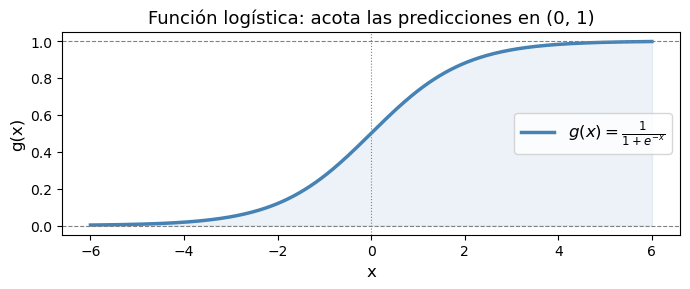

In [3]:
def sigmoid(x):
    """Función logística g(x) = 1 / (1 + exp(-x)).
    Usamos clip para evitar overflow numérico.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


def normalize_ratings(R, K=5):
    """Normaliza calificaciones de [1..K] al intervalo [0, 1].
    t(x) = (x - 1) / (K - 1)
    """
    return (R - 1.0) / (K - 1.0)


def denormalize_ratings(R_norm, K=5):
    """Invierte la normalización: [0,1] → [1..K]."""
    return R_norm * (K - 1.0) + 1.0


def rmse(R_true, R_pred, mask):
    """Calcula RMSE solo sobre las entradas observadas (mask == 1)."""
    diff = (R_true - R_pred)[mask == 1]
    return np.sqrt(np.mean(diff ** 2))


# --- Visualización de la función logística ---
x = np.linspace(-6, 6, 300)
plt.figure(figsize=(7, 3))
plt.plot(x, sigmoid(x), 'steelblue', linewidth=2.5, label=r'$g(x) = \frac{1}{1+e^{-x}}$')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axhline(1, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle=':')
plt.fill_between(x, sigmoid(x), alpha=0.1, color='steelblue')
plt.xlabel('x', fontsize=12)
plt.ylabel('g(x)', fontsize=12)
plt.title('Función logística: acota las predicciones en (0, 1)', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 Clase `PMF`

Encapsulamos el modelo completo en una clase Python que sigue el estilo de scikit-learn.

In [4]:
class PMF:
    """
    Factorización Probabilística de Matrices (Salakhutdinov & Mnih, 2007).

    Parámetros
    ----------
    n_factors : int
        Dimensión del espacio latente D.
    learning_rate : float
        Tasa de aprendizaje η para el gradiente descendente.
    lambda_U : float
        Regularización para los vectores de usuario (λ_U = σ²/σ_U²).
    lambda_V : float
        Regularización para los vectores de ítem (λ_V = σ²/σ_V²).
    n_epochs : int
        Número de épocas (pasadas completas sobre los datos).
    use_logistic : bool
        Si True, aplica la extensión logística del paper.
    """

    def __init__(self, n_factors=10, learning_rate=0.005,
                 lambda_U=0.02, lambda_V=0.02,
                 n_epochs=100, use_logistic=True, verbose=True):
        self.n_factors    = n_factors
        self.lr           = learning_rate
        self.lambda_U     = lambda_U
        self.lambda_V     = lambda_V
        self.n_epochs     = n_epochs
        self.use_logistic = use_logistic
        self.verbose      = verbose

    # ----------------------------------------------------------
    # Inicialización de parámetros
    # ----------------------------------------------------------
    def _init_params(self, n_users, n_items):
        """
        Inicializa U y V con una normal de escala pequeña.
        Esto corresponde al prior gaussiano p(U|σ_U²).
        """
        scale = 0.01
        self.U = np.random.normal(0, scale, (n_users, self.n_factors))  # N × D
        self.V = np.random.normal(0, scale, (n_items, self.n_factors))  # M × D

    # ----------------------------------------------------------
    # Predicción
    # ----------------------------------------------------------
    def _predict_matrix(self):
        """
        Calcula R̂ = g(U Vᵀ) si use_logistic=True,
        o simplemente U Vᵀ si use_logistic=False.
        Retorna una matriz N × M en espacio normalizado [0, 1].
        """
        scores = self.U @ self.V.T  # (N, M)
        if self.use_logistic:
            return sigmoid(scores)
        return scores

    # ----------------------------------------------------------
    # Función objetivo E (para monitorear el entrenamiento)
    # ----------------------------------------------------------
    def _objective(self, R_norm, mask):
        """
        E = ½ Σ_{I_ij=1} (R_ij - R̂_ij)² + (λ_U/2)||U||² + (λ_V/2)||V||²
        """
        R_hat   = self._predict_matrix()
        errors = mask * (R_norm - R_hat)   # aplicar máscara
        sq_err  = 0.5 * np.sum(errors ** 2)
        reg_U   = (self.lambda_U / 2.0) * np.sum(self.U ** 2)
        reg_V   = (self.lambda_V / 2.0) * np.sum(self.V ** 2)
        return sq_err + reg_U + reg_V

    # ----------------------------------------------------------
    # Entrenamiento
    # ----------------------------------------------------------
    def fit(self, R_train, mask_train, R_test=None, mask_test=None, K=5):
        """
        Entrena el modelo PMF por gradiente descendente.

        Parámetros
        ----------
        R_train    : ndarray (N, M) con calificaciones originales (1..K)
        mask_train : ndarray (N, M) con 1s donde hay observación de entrenamiento
        R_test     : ndarray (N, M) con calificaciones de test (opcional)
        mask_test  : ndarray (N, M) con 1s donde hay observación de test
        K          : valor máximo de calificación (default=5)
        """
        n_users, n_items = R_train.shape
        self._init_params(n_users, n_items)

        # Normalizar calificaciones a [0, 1]
        R_norm = normalize_ratings(R_train, K)

        self.train_rmse_hist  = []
        self.test_rmse_hist   = []
        self.obj_hist         = []

        for epoch in range(1, self.n_epochs + 1):

            # ---- Predicción actual ----
            R_hat  = self._predict_matrix()          # [0, 1]
            errors = mask_train * (R_norm - R_hat)   # Errores observados

            # ---- Gradientes (derivados en la Sección 3) ----
            # Si use_logistic, hay que aplicar la regla de la cadena:
            # ∂E/∂(U_i^T V_j) = -error_ij * g'(x) = -error_ij * g(x)(1-g(x))
            if self.use_logistic:
                delta = errors * R_hat * (1.0 - R_hat)  # Regla de la cadena
            else:
                delta = errors

            grad_U = -(delta @ self.V) + self.lambda_U * self.U  # (N, D)
            grad_V = -(delta.T @ self.U) + self.lambda_V * self.V  # (M, D)

            # ---- Actualización ----
            self.U -= self.lr * grad_U
            self.V -= self.lr * grad_V

            # ---- Métricas ----
            obj = self._objective(R_norm, mask_train)
            self.obj_hist.append(obj)

            # RMSE en escala original [1..K]
            R_pred_orig = denormalize_ratings(self._predict_matrix(), K)
            tr_rmse = rmse(R_train, R_pred_orig, mask_train)
            self.train_rmse_hist.append(tr_rmse)

            if R_test is not None:
                te_rmse = rmse(R_test, R_pred_orig, mask_test)
                self.test_rmse_hist.append(te_rmse)

            if self.verbose and (epoch % 10 == 0 or epoch == 1):
                msg = f'Época {epoch:4d}/{self.n_epochs} | Objetivo: {obj:.4f} | RMSE train: {tr_rmse:.4f}'
                if R_test is not None:
                    msg += f' | RMSE test: {te_rmse:.4f}'
                print(msg)

        return self

    # ----------------------------------------------------------
    # Predicción pública
    # ----------------------------------------------------------
    def predict(self, K=5):
        """Devuelve la matriz de predicciones completa en escala [1..K]."""
        return denormalize_ratings(self._predict_matrix(), K)


print('Clase PMF definida ✓')

Clase PMF definida ✓


### 4.3 Verificación con un dataset de juguete

Antes de usar datos reales, construimos un ejemplo pequeño para asegurarnos de que el modelo funciona correctamente.

Matriz de calificaciones (0 = desconocida):
[[5. 3. 0. 1. 0. 4.]
 [4. 0. 4. 1. 2. 0.]
 [0. 3. 0. 5. 4. 0.]
 [1. 0. 2. 4. 0. 3.]
 [0. 4. 3. 0. 5. 4.]]

Entradas observadas: 19 / 30

Matriz de predicciones (escala 1-5):
[[3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3.]
 [3. 3. 3. 3. 3. 3.]]

RMSE final (entradas observadas): 1.3179


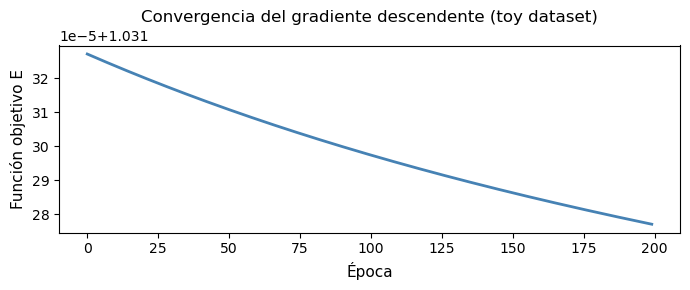

In [11]:
# --- Dataset sintético: 5 usuarios × 6 películas ---
# El valor 0 indica calificación desconocida
R_toy = np.array([
    [5, 3, 0, 1, 0, 4],
    [4, 0, 4, 1, 2, 0],
    [0, 3, 0, 5, 4, 0],
    [1, 0, 2, 4, 0, 3],
    [0, 4, 3, 0, 5, 4],
], dtype=float)

mask_toy = (R_toy > 0).astype(float)

print('Matriz de calificaciones (0 = desconocida):')
print(R_toy)
print(f'\nEntradas observadas: {int(mask_toy.sum())} / {mask_toy.size}')

# Entrenar con el dataset de juguete
model_toy = PMF(n_factors=2, learning_rate=0.01,
                lambda_U=0.1, lambda_V=0.1,
                n_epochs=200, use_logistic=True, verbose=False)

model_toy.fit(R_toy, mask_toy)

R_pred_toy = model_toy.predict()

print('\nMatriz de predicciones (escala 1-5):')
print(np.round(R_pred_toy, 2))

print(f'\nRMSE final (entradas observadas): {model_toy.train_rmse_hist[-1]:.4f}')

# Curva de entrenamiento
plt.figure(figsize=(7, 3))
plt.plot(model_toy.obj_hist, color='steelblue', linewidth=2)
plt.xlabel('Época', fontsize=11)
plt.ylabel('Función objetivo E', fontsize=11)
plt.title('Convergencia del gradiente descendente (toy dataset)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Experimento con MovieLens-100K

El dataset MovieLens 100K es un conjunto de datos ampliamente utilizado en investigación de sistemas de recomendación, recopilado por el GroupLens Research. Contiene 100.000 calificaciones (ratings) realizadas por 943 usuarios sobre 1.682 películas, donde cada usuario ha evaluado al menos 20 películas en una escala discreta de 1 a 5. Además de las interacciones usuario–ítem, el dataset incluye información demográfica básica de los usuarios, como edad, género, ocupación y código postal, así como metadatos de las películas, como título, fecha de lanzamiento y géneros (por ejemplo, acción, comedia o drama). Las calificaciones fueron recolectadas durante un período de siete meses, lo que permite analizar patrones temporales de comportamiento. Debido a su tamaño manejable, estructura limpia y riqueza de información contextual, MovieLens 100K se ha convertido en un benchmark clásico para evaluar algoritmos de filtrado colaborativo, modelos de recomendación basados en contenido y enfoques híbridos en el campo de los sistemas de recomendación.

Vamos a descargarlo directamente desde la URL oficial del GroupLens para realizar los siguientes analisis

> **Nota**: Se recomienda descargar el archivo `.zip` de https://grouplens.org/datasets/movielens/100k/ y descomprimirlo en la misma carpeta que este notebook.

>F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4, Article 19 (December 2015), 19 pages. DOI=http://dx.doi.org/10.1145/2827872

## 5.1 Preparación de los datos

El siguiente fragmento de código se encarga de **preparar el dataset MovieLens-100K**. 

La primera parte define 
- la ubicación del archivo en internet (`DATA_URL`), 
- el nombre de la carpeta donde se guardará (`DATA_DIR`) y 
- el nombre del archivo comprimido (`ZIP_FILE`). 

Luego, el código verifica si el dataset ya existe en el sistema: si no encuentra la carpeta correspondiente, descarga el archivo desde la web y lo descomprime automáticamente. Esto es importante porque hace que el notebook sea **reproducible**: cualquier persona puede ejecutarlo desde cero sin necesidad de descargar manualmente los datos.

Una vez asegurado que los datos están disponibles, el código pasa a cargar un **split oficial de entrenamiento y test** provisto por MovieLens. Creemos que esto es importante desde el punto de vista metodológico: en lugar de dividir los datos arbitrariamente, se utiliza una partición estándar (`u1.base` para entrenamiento y `u1.test` para evaluación), lo que permite comparar resultados con otros trabajos de manera consistente. 

Mediante la variable cols, se definen las columnas disponibles en la base de datos (`user_id`, `item_id`, `rating`, `timestamp`). En este cuaderno de ejercicios se utilizan solo las tres primeras columnas, ya que el timestamp (marca temporal de cada calificación) no es necesaria para el modelo básico. En un futuro podría incorporarse esta variable, para pensar otro tipo de problemas o complejizar el modelo.

Los datos se cargan usando la librería `pandas`, lo que facilita su manipulación posterior. Cada fila representa una interacción entre un usuario y una película, expresada mediante la puntuación otorgada. 

Finalmente, el código imprime la cantidad de registros en cada conjunto (entrenamiento y test) y muestra un pequeño ejemplo de los datos. Creemos que esto último cumple una función pedagógica importante: permite a los estudiantes **visualizar la estructura del dataset** y entender que están trabajando con una matriz dispersa de valoraciones, donde no todos los usuarios califican todos los ítems.


In [5]:
import os
import zipfile
import urllib.request

DATA_URL  = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
DATA_DIR  = 'ml-100k'
ZIP_FILE  = 'ml-100k.zip'

if not os.path.isdir(DATA_DIR):
    print('Descargando MovieLens-100K...')
    urllib.request.urlretrieve(DATA_URL, ZIP_FILE)
    with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
        zf.extractall('.')
    print('Descarga completada ✓')
else:
    print('Dataset ya disponible ✓')

# --- Cargar el split oficial u1.base / u1.test ---
cols = ['user_id', 'item_id', 'rating', 'timestamp']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'u1.base'),
                       sep='\t', names=cols, usecols=[0,1,2])
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'u1.test'),
                       sep='\t', names=cols, usecols=[0,1,2])

print(f'\nRegistros de entrenamiento : {len(df_train):,}')
print(f'Registros de test          : {len(df_test):,}')
print(f'\nEjemplo de los datos:')
df_train.head()

Dataset ya disponible ✓

Registros de entrenamiento : 80,000
Registros de test          : 20,000

Ejemplo de los datos:


,user_id,item_id,rating
0,1,1,5
1,1,2,3
2,1,3,4
3,1,4,3
4,1,5,3


En este fragmento se realiza un paso fundamental en sistemas de recomendación: **transformar los datos tabulares en una representación matricial**. A partir de los registros individuales (usuario, ítem, rating), se construye una matriz ($ R $) de tamaño ( $N_{users} \times N_{items} $), donde cada fila representa un usuario y cada columna una película. Si un usuario calificó una película, ese valor se coloca en la matriz; si no lo hizo, se deja en cero. Este formato es clave porque permite aplicar modelos como la factorización matricial, donde el problema se aborda desde una perspectiva algebraica.

Sin embargo, aparece un problema importante: **los ceros no significan necesariamente una calificación baja, sino datos faltantes**. Para resolver esto, el código construye en paralelo una matriz llamada `mask`, que indica con 1 las posiciones donde hay datos reales y con 0 donde no los hay. Esta máscara es crucial porque el modelo debe aprender únicamente de las observaciones existentes, ignorando las entradas faltantes. Conceptualmente, esto refleja la naturaleza **dispersa (sparse)** del problema: la mayoría de las combinaciones usuario–película no tienen información.

El código también realiza un ajuste técnico importante: convierte los identificadores de usuarios e ítems a indexación desde cero (`0-indexed`), ya que Python utiliza este esquema. Esto evita errores de posicionamiento en la matriz y es una práctica estándar cuando se trabaja con estructuras matriciales.

Una vez construidas las matrices de entrenamiento y test, se calculan estadísticas descriptivas. En particular, se mide la **densidad de la matriz**, es decir, el porcentaje de entradas observadas respecto del total posible. En sistemas de recomendación reales, esta densidad suele ser muy baja, lo que implica que el modelo debe generalizar a partir de muy poca información por usuario. Esta característica es una de las principales dificultades del problema.

Finalmente, el código incluye visualizaciones que ayudan a comprender la estructura de los datos. Por un lado, se muestra la distribución de las calificaciones, lo que permite ver si los usuarios tienden a dar puntuaciones altas, bajas o intermedias. Por otro lado, se analiza cuántas películas califica cada usuario, revelando la **heterogeneidad en la participación**: algunos usuarios son muy activos, mientras que otros apenas interactúan. Estas observaciones son importantes porque influyen directamente en el comportamiento del modelo y en la calidad de las recomendaciones.


Dimensiones de la matriz : 943 usuarios × 1682 películas
Entradas de entrenamiento: 80,000
Entradas de test         : 20,000
Densidad del split train : 5.04%


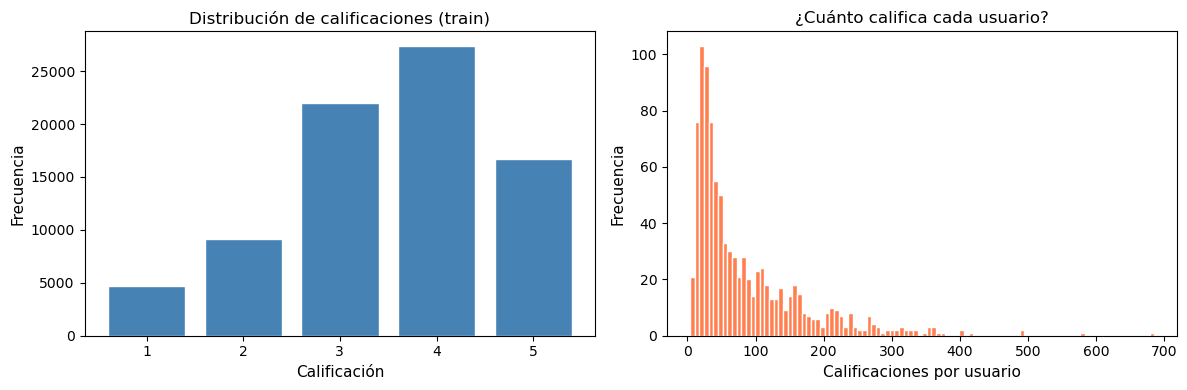

In [11]:
# --- Construir las matrices R y máscaras ---

N_USERS = 943
N_ITEMS = 1682
K_MAX   = 5

def build_matrix(df, n_users, n_items):
    """Construye la matriz R (n_users × n_items) y su máscara."""
    R    = np.zeros((n_users, n_items))
    mask = np.zeros((n_users, n_items))
    for row in df.itertuples(index=False):
        i = row.user_id - 1   # 0-indexed
        j = row.item_id - 1
        R[i, j]    = row.rating
        mask[i, j] = 1.0
    return R, mask

R_train, mask_train = build_matrix(df_train, N_USERS, N_ITEMS)
R_test,  mask_test  = build_matrix(df_test,  N_USERS, N_ITEMS)

# Estadísticas
density = mask_train.sum() / mask_train.size * 100
print(f'Dimensiones de la matriz : {N_USERS} usuarios × {N_ITEMS} películas')
print(f'Entradas de entrenamiento: {int(mask_train.sum()):,}')
print(f'Entradas de test         : {int(mask_test.sum()):,}')
print(f'Densidad del split train : {density:.2f}%')

# Distribución de calificaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['rating'], bins=[0.5,1.5,2.5,3.5,4.5,5.5],
             color='steelblue', edgecolor='white', rwidth=0.8)
axes[0].set_xlabel('Calificación', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de calificaciones (train)', fontsize=12)
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))

ratings_per_user = df_train.groupby('user_id')['rating'].count()
axes[1].hist(ratings_per_user, bins=100, color='coral', edgecolor='white')
axes[1].set_xlabel('Calificaciones por usuario', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('¿Cuánto califica cada usuario?', fontsize=12)

plt.tight_layout()
plt.show()

Detengámonos momentaneamente sobre estos resultados

---

En el primer gráfico, que muestra la **distribución de calificaciones**, se observa claramente que los ratings no están distribuidos de manera uniforme. Hay una fuerte concentración en valores altos, especialmente en 4 y 5. Esto indica un fenómeno muy común en sistemas de recomendación: la presencia de un **sesgo positivo en las evaluaciones**. Es decir, los usuarios tienden a calificar aquello que les gusta, mientras que muchas veces simplemente ignoran lo que no les interesa. Como consecuencia, el dataset no refleja preferencias “neutrales” u “objetivas”, sino más bien una selección de experiencias predominantemente positivas.

Desde el punto de vista del modelado de los datos, esto tiene varias implicancias. Por un lado, el modelo podría aprender a predecir valores altos por defecto, ya que eso minimiza el error promedio. Por otro lado, se pierde información sobre “no me gusta”, lo que dificulta distinguir entre indiferencia y rechazo. Este sesgo también afecta métricas como el RMSE, que pueden parecer buenas incluso si el modelo no captura bien la estructura real del gusto.

---

El segundo gráfico, que muestra cuántas calificaciones realiza cada usuario, revela una propiedad aún más importante: la distribución es **altamente asimétrica (long tail)**. La mayoría de los usuarios tiene pocas interacciones (por ejemplo, menos de 100), mientras que unos pocos usuarios son extremadamente activos, llegando a cientos de ratings.

Esto introduce una heterogeneidad fundamental en los datos:

* Hay usuarios sobre los que sabemos mucho (muchas calificaciones)
* Y otros sobre los que sabemos muy poco

Desde el punto de vista del aprendizaje, esto implica que el modelo puede construir representaciones más confiables para los usuarios activos, mientras que para los usuarios poco activos debe generalizar con mucha incertidumbre. Este problema está directamente relacionado con lo que se conoce como **cold start problem** en la literatura científica.

---

Si conectamos ambos gráficos, aparecen tres aristas que son cruciales para entender el dataset con el que estamos trabajando. En resumidas cuentas, podríamos decir que el conjunto de datos es:

* **Disperso**: la mayoría de las entradas de la matriz están vacías
* **Sesgado**: predominan las calificaciones altas
* **Heterogéneo**: los usuarios tienen comportamientos muy distintos

Ahora bien, no debemos desanimarnos. Estas tres propiedades son, en última instancia, las que justifican el uso de ciertas técnicas como la factorización probabilística de matrices. 

Avanzando un poco más allá de lo indicado por los autores del artículo, podríamos decir que la factorización matricial que se pone en juego en este tipo de escenarios busca justamente **reconstruir la estructura latente del gusto**, a partir de datos incompletos y ruidosos.

---

Desde una perspectiva más conceptual (y conectando con lo que mencionamos al comienzo sobre Bourdieu), estos resultados también pueden interpretarse del siguiente modo:

* El primer gráfico parece hablarnos del **valor simbólico de los objetos culturales**: no todo se evalúa y, aquello que es efectivamente evaluado, tiende a ser percibido de manera positiva.
* El segundo gráfico podría interpretarse como un efecto de las **posiciones y dinámicas de los sujetos en el campo cultural**: algunos individuos participan mucho (usuarios que son expertos o se consideran expertos), mientras que otros individuos apenas interactúan.

En el fondo, lo que queremos lograr mediante estos dos gráficos es reforzar la idea de que un sistema de recomendación no solo modela datos, sino también **prácticas sociales y patrones de participación**.


----
## 5.2 Aprender las representaciones latentes

En este fragmento se instancia y entrena el modelo de **Factorización Probabilística de Matrices (PMF)** sobre el dataset MovieLens, lo que constituye el núcleo del sistema de recomendación. Aquí ya no estamos en la etapa de preparación de datos, sino en el momento en que el modelo comienza a **aprender representaciones latentes** de usuarios y películas.

La inicialización del modelo define varios hiperparámetros clave. En primer lugar, `n_factors = 10` establece la dimensión del espacio latente: cada usuario y cada ítem serán representados como vectores en un espacio de 10 dimensiones. Estas dimensiones no tienen un significado explícito a priori, pero el modelo las aprende de manera que capturen patrones de preferencia. Conceptualmente, podemos pensar que estas dimensiones codifican factores abstractos como “afinidad por cierto tipo de narrativa”, “preferencia por acción vs. drama”, etc., aunque no estén etiquetados directamente.

La `learning_rate` controla qué tan grandes son los pasos que da el modelo en cada iteración del proceso de optimización. Un valor como 0.005 indica un aprendizaje relativamente gradual, lo que ayuda a evitar inestabilidades. Por otro lado, los parámetros `lambda_U` y `lambda_V` introducen **regularización L2** sobre los vectores de usuarios e ítems. Desde una perspectiva probabilística, esto equivale a asumir **priors gaussianos** sobre estos vectores, lo que favorece soluciones “suaves” y evita que el modelo sobreajuste los datos de entrenamiento.

El parámetro `n_epochs = 100` indica cuántas veces el algoritmo recorrerá los datos completos. Cada época representa un ciclo de ajuste de los parámetros, en el que el modelo intenta minimizar el error entre las calificaciones reales y las predichas. Además, se activa `use_logistic = True`, lo que implica que las predicciones no son directamente el producto interno entre vectores, sino que pasan por una función sigmoide. Esto restringe las predicciones a un rango acotado y permite interpretarlas como una especie de “grado de preferencia”, que luego se reescala al rango original de ratings.

El método `fit` es donde ocurre el aprendizaje propiamente dicho. A partir de las matrices de entrenamiento y sus máscaras, el modelo ajusta los vectores latentes para minimizar el error en las entradas observadas. Al mismo tiempo, evalúa su desempeño sobre el conjunto de test en cada época, lo que permite monitorear la capacidad de generalización. Esto es fundamental para detectar fenómenos como el sobreajuste.

Finalmente, se imprime el **RMSE (Root Mean Squared Error)** sobre el conjunto de test, que es una métrica estándar en sistemas de recomendación. Este valor resume qué tan cerca están, en promedio, las predicciones del modelo respecto a las calificaciones reales. Un RMSE más bajo indica mejor desempeño, aunque siempre debe interpretarse en el contexto del problema y compararse con modelos base.

In [12]:
# --- Entrenar PMF sobre MovieLens-100K ---

model = PMF(
    n_factors    = 10,     # D: dimensión del espacio latente
    learning_rate= 0.005,  # η: tasa de aprendizaje
    lambda_U     = 0.02,   # λ_U = σ²/σ_U²
    lambda_V     = 0.02,   # λ_V = σ²/σ_V²
    n_epochs     = 100,
    use_logistic = True,
    verbose      = True
)

model.fit(R_train, mask_train, R_test, mask_test, K=K_MAX)

print(f'\n✓ RMSE final en TEST: {model.test_rmse_hist[-1]:.4f}')

Época    1/100 | Objetivo: 3825.8332 | RMSE train: 1.2371 | RMSE test: 1.2720
Época   10/100 | Objetivo: 3825.7926 | RMSE train: 1.2371 | RMSE test: 1.2720
Época   20/100 | Objetivo: 3825.7451 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   30/100 | Objetivo: 3825.6907 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   40/100 | Objetivo: 3825.6224 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   50/100 | Objetivo: 3825.5256 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   60/100 | Objetivo: 3825.3710 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   70/100 | Objetivo: 3825.0971 | RMSE train: 1.2369 | RMSE test: 1.2720
Época   80/100 | Objetivo: 3824.5739 | RMSE train: 1.2369 | RMSE test: 1.2720
Época   90/100 | Objetivo: 3823.5255 | RMSE train: 1.2367 | RMSE test: 1.2718
Época  100/100 | Objetivo: 3821.3660 | RMSE train: 1.2363 | RMSE test: 1.2716

✓ RMSE final en TEST: 1.2716


Estos resultados muestran la evolución del entrenamiento del modelo a lo largo de las épocas, y permiten hacer una lectura muy rica sobre **cómo está aprendiendo (o no) el modelo**.

En primer lugar, se observa que la **función objetivo** disminuye de manera sostenida a lo largo de las épocas. Esto es una buena señal: indica que el algoritmo de optimización está funcionando correctamente y que el modelo está encontrando configuraciones de los parámetros que reducen el error total (incluyendo la regularización). Es decir, desde el punto de vista matemático, el modelo está “aprendiendo”.

Sin embargo, cuando miramos el **RMSE en entrenamiento y test**, aparece un fenómeno mucho más interesante: ambos valores prácticamente no cambian. El RMSE de entrenamiento pasa de aproximadamente 1.2371 a 1.2363, y el de test de 1.2720 a 1.2716. Esta mejora es extremadamente pequeña, casi marginal. Esto sugiere que, aunque la función objetivo disminuye, el modelo no está logrando mejorar significativamente su capacidad predictiva.

Esto puede interpretarse de varias maneras. Una posibilidad es que el modelo esté en una especie de **meseta de aprendizaje**, donde los gradientes son muy pequeños y los cambios en los parámetros apenas afectan las predicciones. Otra posibilidad es que la **tasa de aprendizaje sea demasiado baja**, lo que hace que el entrenamiento avance muy lentamente. También podría estar influyendo la regularización: valores relativamente altos de `lambda_U` y `lambda_V` pueden estar restringiendo demasiado los vectores latentes, impidiendo que el modelo capture patrones más complejos.

Otro punto clave es que **no hay señales de sobreajuste**. El RMSE de entrenamiento y de test se mantienen muy cercanos entre sí durante todo el proceso. Esto indica que el modelo no está memorizando los datos de entrenamiento, sino que se comporta de manera similar en datos no vistos. Desde una perspectiva clásica de machine learning, esto es bueno, pero también puede ser una señal de **subajuste (underfitting)**: el modelo es demasiado simple o está demasiado restringido para capturar la estructura real de los datos.

En términos conceptuales, esto sugiere que el espacio latente de dimensión 10, junto con la configuración actual de hiperparámetros, no está siendo suficiente para representar adecuadamente la complejidad del gusto de los usuarios. El modelo está aprendiendo algo, pero ese “algo” no es lo suficientemente expresivo como para mejorar sustancialmente las predicciones.

En resumen, estos resultados muestran un caso típico donde el modelo es **estable pero poco expresivo**. No diverge, no sobreajusta, pero tampoco mejora mucho. Esto abre la puerta a explorar modificaciones como aumentar la dimensión latente, ajustar la regularización, cambiar la tasa de aprendizaje o incluso enriquecer el modelo (por ejemplo, incorporando bias de usuario e ítem), con el objetivo de capturar mejor la estructura subyacente de los datos.


In [20]:
import itertools
import pandas as pd

# --- Definir el espacio de búsqueda ---
param_grid = {
    "n_factors": [10, 20, 30],
    "learning_rate": [0.005, 0.01],
    "lambda_U": [0.01, 0.02],
    "lambda_V": [0.01, 0.02],
}

# Generar combinaciones
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []

print(f"Probando {len(combinations)} configuraciones...\n")

# --- Loop principal ---
for i, params in enumerate(combinations):
    print(f"Configuración {i+1}/{len(combinations)}: {params}")
    
    model = PMF(
        n_factors     = params["n_factors"],
        learning_rate = params["learning_rate"],
        lambda_U      = params["lambda_U"],
        lambda_V      = params["lambda_V"],
        n_epochs      = 100,
        use_logistic  = True,
        verbose       = False
    )
    
    model.fit(R_train, mask_train, R_test, mask_test, K=K_MAX)
    
    final_rmse_test  = model.test_rmse_hist[-1]
    final_rmse_train = model.train_rmse_hist[-1]
    
    gap = final_rmse_test - final_rmse_train  # clave para diagnóstico
    
    results.append({
        **params,
        "rmse_train": final_rmse_train,
        "rmse_test": final_rmse_test,
        "gap": gap
    })
    
    print(f"→ RMSE train: {final_rmse_train:.4f} | RMSE test: {final_rmse_test:.4f} | gap: {gap:.4f}\n")

# --- Convertir a DataFrame ---
results_df = pd.DataFrame(results)

# Ordenar por mejor desempeño en test
results_df = results_df.sort_values(by="rmse_test")

print("\n🏆 Mejores configuraciones:")
print(results_df.head(10))

Probando 24 configuraciones...

Configuración 1/24: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_U': 0.01, 'lambda_V': 0.01}
→ RMSE train: 1.2362 | RMSE test: 1.2715 | gap: 0.0353

Configuración 2/24: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_U': 0.01, 'lambda_V': 0.02}
→ RMSE train: 1.2354 | RMSE test: 1.2710 | gap: 0.0356

Configuración 3/24: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_U': 0.02, 'lambda_V': 0.01}
→ RMSE train: 1.2365 | RMSE test: 1.2717 | gap: 0.0352

Configuración 4/24: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_U': 0.02, 'lambda_V': 0.02}
→ RMSE train: 1.2360 | RMSE test: 1.2714 | gap: 0.0354

Configuración 5/24: {'n_factors': 10, 'learning_rate': 0.01, 'lambda_U': 0.01, 'lambda_V': 0.01}
→ RMSE train: 1.0493 | RMSE test: 1.1073 | gap: 0.0580

Configuración 6/24: {'n_factors': 10, 'learning_rate': 0.01, 'lambda_U': 0.01, 'lambda_V': 0.02}
→ RMSE train: 1.0750 | RMSE test: 1.1346 | gap: 0.0596

Configuración 7/24: {'n_factors': 10, 'learnin

Estos resultados muestran que el mejor desempeño del modelo se alcanza consistentemente cuando se utiliza una **dimensión latente más alta (n_factors = 30)** junto con una **tasa de aprendizaje de 0.01**, lo que indica que el modelo necesita mayor capacidad representacional y pasos de optimización más grandes para capturar adecuadamente la estructura de los datos. A medida que disminuye la cantidad de factores (por ejemplo, 20 o 10), el RMSE tanto en entrenamiento como en test empeora, lo que sugiere un cierto grado de **underfitting** en modelos más pequeños. 

Por otro lado, la diferencia entre RMSE de entrenamiento y test (gap) se mantiene relativamente baja y estable en todas las configuraciones (alrededor de 0.05), lo que indica que **no hay evidencia fuerte de overfitting**: el modelo generaliza de manera bastante consistente. En conjunto, esto sugiere que el principal límite del rendimiento no es el sobreajuste, sino la capacidad del modelo, y que aumentar la dimensionalidad del espacio latente mejora la calidad de las predicciones sin comprometer la generalización.


In [13]:
# --- Volvemos a entrenar PMF sobre MovieLens-100K usando los nuevos parámetros---

model = PMF(
    n_factors    = 30,     # D: dimensión del espacio latente
    learning_rate= 0.01,  # η: tasa de aprendizaje
    lambda_U     = 0.02,   # λ_U = σ²/σ_U²
    lambda_V     = 0.01,   # λ_V = σ²/σ_V²
    n_epochs     = 100,
    use_logistic = True,
    verbose      = True
)

model.fit(R_train, mask_train, R_test, mask_test, K=K_MAX)

print(f'\n✓ RMSE final en TEST: {model.test_rmse_hist[-1]:.4f}')

Época    1/100 | Objetivo: 3825.8360 | RMSE train: 1.2371 | RMSE test: 1.2720
Época   10/100 | Objetivo: 3825.5614 | RMSE train: 1.2370 | RMSE test: 1.2720
Época   20/100 | Objetivo: 3825.1031 | RMSE train: 1.2369 | RMSE test: 1.2720
Época   30/100 | Objetivo: 3823.9595 | RMSE train: 1.2368 | RMSE test: 1.2719
Época   40/100 | Objetivo: 3819.8880 | RMSE train: 1.2361 | RMSE test: 1.2715
Época   50/100 | Objetivo: 3803.2160 | RMSE train: 1.2334 | RMSE test: 1.2697
Época   60/100 | Objetivo: 3735.1516 | RMSE train: 1.2223 | RMSE test: 1.2619
Época   70/100 | Objetivo: 3507.9907 | RMSE train: 1.1844 | RMSE test: 1.2339
Época   80/100 | Objetivo: 3098.9513 | RMSE train: 1.1130 | RMSE test: 1.1731
Época   90/100 | Objetivo: 2773.8039 | RMSE train: 1.0527 | RMSE test: 1.1112
Época  100/100 | Objetivo: 2597.1601 | RMSE train: 1.0183 | RMSE test: 1.0719

✓ RMSE final en TEST: 1.0719


El siguiente fragmento de código se enfoca en una etapa clave del análisis de modelos: la **visualización del proceso de aprendizaje**. En lugar de mirar únicamente el resultado final, aquí se observa cómo evoluciona el modelo a lo largo de las épocas, lo que permite entender si realmente está aprendiendo, si converge correctamente o si presenta problemas como sobreajuste o estancamiento.

En el primer gráfico se representa la **función objetivo** (la cantidad que el modelo intenta minimizar) en función de las épocas. Esta curva muestra el comportamiento del proceso de optimización: si desciende de manera suave y sostenida, indica que el algoritmo está funcionando correctamente y acercándose a una solución óptima. Si, en cambio, la curva fuera errática o creciente, sería señal de problemas en el entrenamiento, como una tasa de aprendizaje inadecuada. Desde un punto de vista conceptual, este gráfico refleja el proceso interno del modelo, cómo ajusta sus parámetros para explicar mejor los datos observados.

El segundo gráfico compara el **RMSE en entrenamiento y en test** a lo largo del tiempo, lo cual es fundamental para evaluar la capacidad de generalización. La curva de entrenamiento muestra qué tan bien el modelo se ajusta a los datos que vio, mientras que la curva de test indica qué tan bien puede predecir datos nuevos. La relación entre ambas curvas es especialmente informativa: si ambas disminuyen y se mantienen cercanas, el modelo generaliza bien; si la de entrenamiento baja mucho pero la de test comienza a subir, aparece el sobreajuste; y si ambas se mantienen altas, estamos ante un caso de subajuste.

Finalmente, el código imprime el **mínimo RMSE en test y la época en la que ocurre**, lo cual permite identificar el mejor punto del entrenamiento. Esto es importante porque el mejor modelo no necesariamente es el de la última época, sino aquel que logra el mejor equilibrio entre ajuste y generalización. Este concepto es la base de técnicas como el *early stopping*, donde se detiene el entrenamiento en el momento óptimo para evitar que el modelo comience a deteriorar su desempeño en datos no vistos.


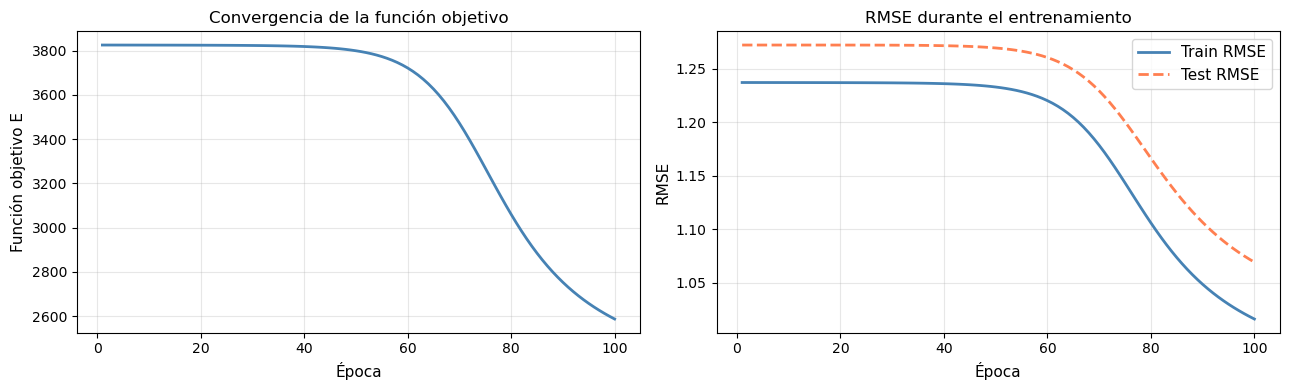

RMSE mínimo en test : 1.0693 (época 100)


In [31]:
# --- Curvas de aprendizaje ---

epochs = range(1, model.n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Función objetivo
axes[0].plot(epochs, model.obj_hist, color='steelblue', linewidth=2)
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Función objetivo E', fontsize=11)
axes[0].set_title('Convergencia de la función objetivo', fontsize=12)
axes[0].grid(True, alpha=0.3)

# RMSE train vs test
axes[1].plot(epochs, model.train_rmse_hist, label='Train RMSE',
             color='steelblue', linewidth=2)
axes[1].plot(epochs, model.test_rmse_hist,  label='Test RMSE',
             color='coral', linewidth=2, linestyle='--')
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_title('RMSE durante el entrenamiento', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'RMSE mínimo en test : {min(model.test_rmse_hist):.4f} (época {np.argmin(model.test_rmse_hist)+1})')

Estos resultados muestran un comportamiento muy interesante del modelo y permiten hacer una lectura bastante rica del proceso de aprendizaje.

En el primer gráfico (izquierda), correspondiente a la **función objetivo**, se ve una curva que se mantiene casi plana en las primeras épocas y luego desciende de forma sostenida desde alrededor de la época 60 en adelante, pasando de ~3800 a ~2600. Esto nos indica que la función de pérdida que reconstruimos a partir del artículo parece funcionar correctamente.

En el segundo gráfico (derecha), se observa que tanto el **RMSE de entrenamiento como el de test disminuyen de manera sostenida**, especialmente a partir de aproximadamente la época 60–70. Esto indica que el modelo comienza a capturar patrones relevantes en los datos en esa etapa del entrenamiento. Antes de ese punto, el aprendizaje es muy lento (una especie de “meseta”), lo que sugiere que los parámetros iniciales o la configuración del modelo hacen que tarde en encontrar una dirección útil en el espacio de optimización.

Un aspecto particularmente importante es que **las curvas de entrenamiento y test se mantienen cercanas en todo momento**, sin separarse significativamente. Esto indica que no hay señales de sobreajuste: el modelo no está memorizando los datos, sino que generaliza bien.

El hecho de que el **mejor RMSE en test se alcance en la última época (época 100)** indica que el modelo aún no ha terminado de converger completamente. Es decir, si se continuara el entrenamiento, es probable que el error siga disminuyendo. Esto refuerza la idea de que el modelo no está sobreajustando, sino más bien que todavía tiene margen para mejorar.

---

La función objetivo es lo que el modelo optimiza internamente, mientras que el RMSE es una métrica externa que usamos para evaluar la calidad de las predicciones. En este caso, ambas cantidades comienzan a descender en paralelo alrededor de la época 60, lo que indica que el modelo está optimizando una función que está alineada con el desempeño predictivo.

Este punto es importante conceptualmente: el RMSE no es “la única métrica que interesa”, sino una elección específica que depende del problema. En sistemas de recomendación, podríamos interesarnos también por otras métricas (ranking, precisión top-K, etc.). Sin embargo, en este contexto particular, donde el modelo está formulado como una regresión sobre ratings, el RMSE es una medida natural de qué tan cerca están las predicciones de los valores reales. Por eso lo usamos como referencia para juzgar el modelo.


# 6. Ejemplo de uso como recomendador

In [6]:
def cargar_nombres_peliculas(data_dir):
    movie_cols = ['item_id', 'title']
    df_movies = pd.read_csv(
        os.path.join(data_dir, 'u.item'),
        sep='|',
        encoding='latin-1',
        names=[ 'item_id', 'title', 'release_date', 'video_release',
                'IMDb_URL'] + list(range(19)),
        usecols=[0, 1]
    )
    return dict(zip(df_movies.item_id - 1, df_movies.title))  # 0-index
movie_names = cargar_nombres_peliculas(DATA_DIR)

In [7]:
def recomendar_peliculas(model, R_train, user_id, movie_names, top_k=10):
    user_idx = user_id - 1
    
    R_pred = model.predict(K=K_MAX)
    
    # Películas ya vistas
    ya_vistas = R_train[user_idx] > 0
    
    scores = R_pred[user_idx].copy()
    
    # Evitar recomendar ya vistas
    scores[ya_vistas] = -np.inf
    
    top_items = np.argsort(scores)[-top_k:][::-1]
    
    print(f"\n🎯 Recomendaciones para usuario {user_id}:\n")
    for i, item in enumerate(top_items):
        print(f"{i+1}. {movie_names.get(item, 'Desconocida')} (score: {scores[item]:.2f})")

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

def peliculas_similares(model, item_id, movie_names, top_k=10):
    item_idx = item_id - 1
    
    V = model.V
    sims = cosine_similarity(V[item_idx].reshape(1, -1), V).flatten()
    
    sims[item_idx] = -1  # excluir la misma
    
    top_items = np.argsort(sims)[-top_k:][::-1]
    
    print(f"\n🎬 Películas similares a: {movie_names.get(item_idx, 'Desconocida')}\n")
    for i, item in enumerate(top_items):
        print(f"{i+1}. {movie_names.get(item, 'Desconocida')} (sim: {sims[item]:.3f})")

In [14]:
# Recomendaciones
recomendar_peliculas(model, R_train, user_id=10, movie_names=movie_names)

# Similitud
peliculas_similares(model, item_id=50, movie_names=movie_names)


🎯 Recomendaciones para usuario 10:

1. Godfather, The (1972) (score: 4.54)
2. Schindler's List (1993) (score: 4.51)
3. Silence of the Lambs, The (1991) (score: 4.47)
4. Fargo (1996) (score: 4.44)
5. Shawshank Redemption, The (1994) (score: 4.44)
6. Empire Strikes Back, The (1980) (score: 4.44)
7. Return of the Jedi (1983) (score: 4.41)
8. Casablanca (1942) (score: 4.41)
9. Princess Bride, The (1987) (score: 4.37)
10. Pulp Fiction (1994) (score: 4.31)

🎬 Películas similares a: Star Wars (1977)

1. Return of the Jedi (1983) (sim: 0.998)
2. Empire Strikes Back, The (1980) (sim: 0.996)
3. Hunt for Red October, The (1990) (sim: 0.996)
4. Toy Story (1995) (sim: 0.995)
5. Wizard of Oz, The (1939) (sim: 0.995)
6. Dead Poets Society (1989) (sim: 0.995)
7. Schindler's List (1993) (sim: 0.995)
8. Fugitive, The (1993) (sim: 0.995)
9. Raiders of the Lost Ark (1981) (sim: 0.995)
10. Babe (1995) (sim: 0.995)
